# Chapter 10 - Relational Deep Reinforcement Learning
### Deep Reinforcement Learning *in Action*
Based on paper by Zambaldi et al 2018 < https://arxiv.org/abs/1806.01830 >

In [0]:
import numpy as np
from matplotlib import pyplot as plt
import torch
from random import shuffle
from torch import nn
import torchvision as TV
from torch.utils.tensorboard import SummaryWriter
from collections import deque
!pip install gym-minigrid
!pip install -q tf-nightly-2.0-preview
!pip install einops
from einops import rearrange, reduce
# Load the TensorBoard notebook extension
%load_ext tensorboard

     |████████████████████████████████| 51kB 2.1MB/s 
     |████████████████████████████████| 62.2MB 65.4MB/s 
     |████████████████████████████████| 71kB 25.4MB/s 
     |████████████████████████████████| 90.8MB 40.5MB/s 
     |████████████████████████████████| 3.8MB 30.1MB/s 
     |████████████████████████████████| 450kB 44.0MB/s 


In [0]:
def running_mean(x,w=50,step=1):
    c = 1.0/w
    conv = np.array([c]).repeat(w)
    output = []
    s,e = 0,w
    for i in range(x.shape[0]):
        sub = x[s:e]
        if sub.shape[0] < w:
            break
        tmp = conv @ sub
        output.append(tmp)
        s = s + step
        e = s + w
    return np.array(output)

# MNIST

Will use curiosity mechanism from "Self-Supervised Exploration via Disagreement" Pathek et al 2019.

In [0]:
class RelationalModule(torch.nn.Module):
    def __init__(self):
        super(RelationalModule, self).__init__()
        self.conv1_ch = 16 
        self.conv2_ch = 20 #dim `F` in paper
        self.conv3_ch = 24
        self.conv4_ch = 30
        self.H = 28
        self.W = 28
        self.entity_size = 36 #dim `E`, desired entity embedding size
        self.lin_hid = 100
        self.out_dim = 10
        self.ch_in = 1
        self.sp_coord_dim = 2
        self.N = int(16**2)
        #
        self.conv1 = nn.Conv2d(self.ch_in,self.conv1_ch,kernel_size=(4,4)).cuda()
        self.conv2 = nn.Conv2d(self.conv1_ch,self.conv2_ch,kernel_size=(4,4)).cuda()
        self.conv3 = nn.Conv2d(self.conv2_ch,self.conv3_ch,kernel_size=(4,4)).cuda()
        self.conv4 = nn.Conv2d(self.conv3_ch,self.conv4_ch,kernel_size=(4,4)).cuda()
        #
        self.proj_shape = (self.conv4_ch+self.sp_coord_dim,self.entity_size)
        self.k_proj = nn.Linear(*self.proj_shape).cuda()
        self.q_proj = nn.Linear(*self.proj_shape).cuda()
        self.v_proj = nn.Linear(*self.proj_shape).cuda()
        #
        self.node_shape = (self.N,self.entity_size)
        #
        self.k_lin = nn.Linear(self.entity_size,self.N).cuda()
        self.q_lin = nn.Linear(self.entity_size,self.N).cuda()
        #
        
        self.k_norm = nn.LayerNorm(self.node_shape, elementwise_affine=True).cuda()
        self.q_norm = nn.LayerNorm(self.node_shape, elementwise_affine=True).cuda()
        self.v_norm = nn.LayerNorm(self.node_shape, elementwise_affine=True).cuda()
        #
        self.linear1 = nn.Linear(self.entity_size, self.entity_size).cuda()
        self.norm1 = nn.LayerNorm([self.N,self.entity_size], elementwise_affine=False).cuda()
        self.linear2 = nn.Linear(self.entity_size, self.out_dim).cuda()
    
    def forward(self,x):
        """
        `x` is a tensor (Batch_Size, C_{in}, Depth=1, Ht, Wt)
        """
        N, Cin, H, W = x.shape
        x = self.conv1(x) 
        x = torch.relu(x)
        x = self.conv2(x) 
        x = x.squeeze() 
        x = torch.relu(x) 
        x = self.conv3(x)
        x = torch.relu(x)
        x = self.conv4(x)
        x = torch.relu(x)

        _,_,cH,cW = x.shape
        xcoords = torch.arange(cW).repeat(cH,1).float().cuda() / cW
        ycoords = torch.arange(cH).repeat(cW,1).transpose(1,0).float().cuda() / cH
        spatial_coords = torch.stack([xcoords,ycoords],dim=0)
        spatial_coords = spatial_coords.unsqueeze(dim=0)
        spatial_coords = spatial_coords.repeat(N,1,1,1)
        x = torch.cat([x,spatial_coords],dim=1)
        x = x.permute(0,2,3,1)
        x = x.flatten(1,2)
        
        K = self.k_proj(x)
        K = self.k_norm(K) 
        
        Q = self.q_proj(x)
        Q = self.q_norm(Q) 
        
        V = self.v_proj(x)
        V = self.v_norm(V) 
        A = torch.einsum('bfe,bge->bfg',Q,K) 
        A = A / np.sqrt(self.entity_size)
        #A = torch.nn.functional.elu(self.q_lin(Q) + self.k_lin(K))
        A = torch.nn.functional.softmax(A,dim=2) 
        with torch.no_grad():
            self.att_map = A.cpu().clone()
        E = torch.einsum('bfc,bcd->bfd',A,V)
        E = self.linear1(E)
        E = torch.relu(E)
        E = self.norm1(E)
        E = E.max(dim=1)[0]
        y = self.linear2(E)
        y = torch.nn.functional.log_softmax(y,dim=1)
        return y

In [0]:
RelationalModule()(torch.randn(2,1,28,28).cuda()).shape

torch.Size([2, 10])

In [0]:
mnist_data = TV.datasets.MNIST("MNIST/", train=True, transform=None,\
                                        target_transform=None, download=True)
mnist_test = TV.datasets.MNIST("MNIST/", train=False, transform=None,\
                                        target_transform=None, download=True)

0it [00:00, ?it/s]

9920512it [00:02, 3682865.41it/s]                             


Extracting MNIST/MNIST/raw/train-images-idx3-ubyte.gz


0it [00:00, ?it/s]

32768it [00:00, 57256.64it/s]                           
0it [00:00, ?it/s]

Extracting MNIST/MNIST/raw/train-labels-idx1-ubyte.gz


1654784it [00:01, 952133.83it/s]                             
0it [00:00, ?it/s]

Extracting MNIST/MNIST/raw/t10k-images-idx3-ubyte.gz


8192it [00:00, 21984.90it/s]            

Extracting MNIST/MNIST/raw/t10k-labels-idx1-ubyte.gz
Processing...
Done!


In [0]:
def add_spots(x,m=20,std=5,val=1):
    mask = torch.zeros(x.shape)
    N = int(m + std * np.abs(np.random.randn()))
    ids = np.random.randint(np.prod(x.shape),size=N)
    mask.view(-1)[ids] = val
    return torch.clamp(x + mask,0,1)

def prepare_images(xt,maxtrans=0,rot=0,noise=0):
    """
    Takes an image batch encoded as 0-255 integer pixel values, normalizes to 0 to 1
    """
    out = torch.zeros(xt.shape)
    for i in range(xt.shape[0]):
        #random translation and noise
        img = xt[i].unsqueeze(dim=0)
        img = TV.transforms.functional.to_pil_image(img)
        rand_rot = np.random.randint(-1*rot,rot,1) if rot > 0 else 0
        xtrans,ytrans = np.random.randint(-maxtrans,maxtrans,2) if maxtrans > 0 else (0,0)
        img = TV.transforms.functional.affine(img, rand_rot, (xtrans,ytrans),1,0)
        img = TV.transforms.functional.to_tensor(img).squeeze()
        if noise > 0:
            img = add_spots(img,m=noise)
        #re-scale to 0-1
        maxval = img.view(-1).max()
        if maxval > 0:
            img = img.float() / maxval
        else:
            img = img.float()
        out[i] = img
    return out

In [0]:
%%time
agent = RelationalModule()
#Test train on MNIST
writer = SummaryWriter()
epochs = 1000
batch_size=300
lr = 1e-3
lossfn = nn.NLLLoss()
opt = torch.optim.Adam(params=agent.parameters(),lr=lr)
losses = []
acc = []
for i in range(epochs):
    opt.zero_grad()
    batch_ids = np.random.randint(0,60000,size=batch_size)
    xt = mnist_data.data[batch_ids].detach()
    xt = prepare_images(xt,rot=30).unsqueeze(dim=1) #add chanel dimension
    yt = mnist_data.targets[batch_ids].detach()
    #
    pred = agent(xt.cuda()).cpu()
    pred_labels = torch.argmax(pred,dim=1)
    acc_ = 100.0 * (pred_labels == yt).sum() / batch_size
    acc.append(acc_)
    correct = torch.zeros(batch_size,10)
    rows = torch.arange(batch_size).long()
    correct[[rows,yt.detach().long()]] = 1.
    loss = lossfn(pred,yt)
    losses.append(loss.detach().numpy())
    writer.add_scalar('Loss/train', loss.detach().numpy(), i)
    writer.add_scalar('Acc/train', acc_.detach().numpy(), i)
    loss.backward()
    opt.step()
losses = np.array(losses)
acc = np.array(acc)

CPU times: user 2min 13s, sys: 10.5 s, total: 2min 24s
Wall time: 2min 24s


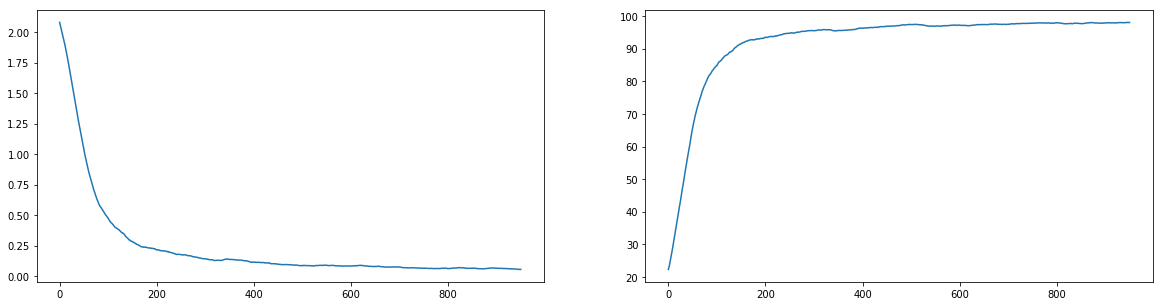

In [0]:
fig,ax = plt.subplots(1,2)
fig.set_size_inches(20,5)
ax[0].plot(running_mean(losses))
ax[1].plot(running_mean(acc))

In [0]:
def test_acc(model,batch_size=500):
    acc = 0.
    batch_ids = np.random.randint(0,10000,size=batch_size)
    xt = mnist_test.data[batch_ids].detach() #batch_size x 28,28
    xt = prepare_images(xt,rot=30).unsqueeze(dim=1)
    yt = mnist_test.targets[batch_ids].detach()
    preds = model(xt.cuda()).cpu()
    pred_ind = torch.argmax(preds.detach(),dim=1)
    acc = (pred_ind == yt).sum().float() / batch_size
    return acc, xt, yt

In [0]:
#79% test acc for 1000 epochs w/ spatial coords, batch size 50
acc2, xt2, yt2 = test_acc(agent)
print(acc2)

tensor(0.8940)


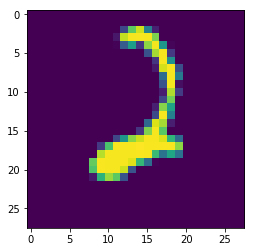

In [0]:
plt.imshow(xt2[0][0])

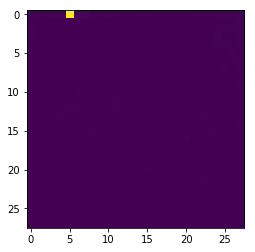

In [0]:
att = agent.att_map.cpu()[40].mean(dim=0).view(28,28)
plt.imshow(att)

# Gridworld

In [0]:
class MultiHeadRelationalModule(torch.nn.Module):
    def __init__(self):
        super(MultiHeadRelationalModule, self).__init__()
        self.conv1_ch = 16 
        self.conv2_ch = 20 #dim `F` in paper
        self.conv3_ch = 24
        self.conv4_ch = 30
        self.H = 28
        self.W = 28
        self.node_size = 64 #dim `E`, desired entity embedding size
        self.lin_hid = 100
        self.out_dim = 5
        self.ch_in = 3
        self.sp_coord_dim = 2
        self.N = int(7**2)
        self.n_heads = 3
        #
        self.conv1 = nn.Conv2d(self.ch_in,self.conv1_ch,kernel_size=(1,1),padding=0).cuda()
        self.conv2 = nn.Conv2d(self.conv1_ch,self.conv2_ch,kernel_size=(1,1),padding=0).cuda()
        #self.conv3 = nn.Conv2d(self.conv2_ch,self.conv3_ch,kernel_size=(3,3),padding=1).cuda()
        #self.conv4 = nn.Conv2d(self.conv3_ch,self.conv4_ch,kernel_size=(3,3),padding=1).cuda()
        #
        self.proj_shape = (self.conv2_ch+self.sp_coord_dim,self.n_heads * self.node_size)
        self.k_proj = nn.Linear(*self.proj_shape).cuda()
        self.q_proj = nn.Linear(*self.proj_shape).cuda()
        self.v_proj = nn.Linear(*self.proj_shape).cuda()
        
        #
        self.k_lin = nn.Linear(self.node_size,self.N).cuda()
        self.q_lin = nn.Linear(self.node_size,self.N).cuda()
        self.a_lin = nn.Linear(self.N,self.N).cuda()
        #
        self.node_shape = (self.n_heads, self.N,self.node_size)
        self.k_norm = nn.LayerNorm(self.node_shape, elementwise_affine=True).cuda()
        self.q_norm = nn.LayerNorm(self.node_shape, elementwise_affine=True).cuda()
        self.v_norm = nn.LayerNorm(self.node_shape, elementwise_affine=True).cuda()
        #
        self.linear1 = nn.Linear(self.n_heads * self.node_size, self.node_size).cuda()
        self.norm1 = nn.LayerNorm([self.N,self.node_size], elementwise_affine=False).cuda()
        self.linear2 = nn.Linear(self.node_size, self.out_dim).cuda()
    
    def forward(self,x):
        """
        `x` is a tensor (Batch_Size, C_{in}, Depth=1, Ht, Wt)
        """
        N, Cin, H, W = x.shape
        x = self.conv1(x) 
        x = torch.relu(x)
        x = self.conv2(x) 
        x = torch.relu(x) 
        #x = self.conv3(x)
        #x = torch.relu(x)
        #x = self.conv4(x)
        #x = torch.relu(x)
        with torch.no_grad():
            self.conv_map = x.cpu().clone()
        _,_,cH,cW = x.shape
        xcoords = torch.arange(cW).repeat(cH,1).float().cuda() / cW
        ycoords = torch.arange(cH).repeat(cW,1).transpose(1,0).float().cuda() / cH
        spatial_coords = torch.stack([xcoords,ycoords],dim=0)
        spatial_coords = spatial_coords.unsqueeze(dim=0)
        spatial_coords = spatial_coords.repeat(N,1,1,1)
        x = torch.cat([x,spatial_coords],dim=1)
        x = x.permute(0,2,3,1)
        x = x.flatten(1,2)
        
        K = rearrange(self.k_proj(x), "b n (head d) -> b head n d", head=self.n_heads)
        K = self.k_norm(K) 
        
        Q = rearrange(self.q_proj(x), "b n (head d) -> b head n d", head=self.n_heads)
        Q = self.q_norm(Q) 
        
        V = rearrange(self.v_proj(x), "b n (head d) -> b head n d", head=self.n_heads)
        V = self.v_norm(V) 
        #A = torch.einsum('bfe,bge->bfg',Q,K) 
        #A = A / np.sqrt(self.node_size)
        #B H N D @ D N -> B H N N
        A = torch.nn.functional.elu(self.q_lin(Q) + self.k_lin(K))
        A = self.a_lin(A)
        A = torch.nn.functional.softmax(A,dim=3) 
        with torch.no_grad():
            self.att_map = A.cpu().clone()
        E = torch.einsum('bhfc,bhcd->bhfd',A,V)
        #collapse head dimension
        E = rearrange(E, 'b head n d -> b n (head d)')
        # B N D' . D' D -> B N D
        E = self.linear1(E)
        E = torch.relu(E)
        E = self.norm1(E)
        # B N D -> B D
        E = E.max(dim=1)[0]
        y = self.linear2(E)
        y = torch.nn.functional.elu(y)
        return y

In [0]:
MultiHeadRelationalModule()(torch.randn(2,3,7,7).cuda()).shape

torch.Size([2, 5])

In [0]:
import gym
from gym_minigrid.minigrid import *
from gym_minigrid.wrappers import FullyObsWrapper, ImgObsWrapper
from skimage.transform import resize

In [0]:
def prepare_state(x):
    """
    Takes raw RGB numpy state from env and downsamples to 36x66
    and converts to torch tensor of dim 3x11x6 and normalizes values to 0-1
    """
    ns = torch.from_numpy(x).float().permute(2,0,1).unsqueeze(dim=0)#
    maxv = ns.flatten().max()
    ns = ns / maxv
    return ns
  
def prepare_state_norm(x):
    """
    Takes raw RGB numpy state from env and downsamples to 36x66
    and converts to torch tensor of dim 3x11x6 and normalizes values to 0-1
    """
    ns = torch.from_numpy(x).float().permute(2,0,1).unsqueeze(dim=0)#
    meanv = ns.flatten().mean()
    #maxv = ns.flatten().max()
    std = ns.flatten().std()
    ns = (ns - meanv) / std
    #ns = ns / maxv
    return ns

In [0]:
def get_minibatch(replay,size):
    """
    Returns a random subset of experiences from the experience replay memory
    """
    batch_ids = np.random.randint(0,len(replay),size)
    batch = [replay[x] for x in batch_ids] #list of tuples
    state_batch = torch.cat([s for (s,a,r,s2,d) in batch],)
    action_batch = torch.Tensor([a for (s,a,r,s2,d) in batch]).long()
    reward_batch = torch.Tensor([r for (s,a,r,s2,d) in batch])
    state2_batch = torch.cat([s2 for (s,a,r,s2,d) in batch],dim=0)
    done_batch = torch.Tensor([d for (s,a,r,s2,d) in batch])
    return state_batch,action_batch,reward_batch,state2_batch, done_batch

def get_qtarget(qvals,r,df,done):
    """
    `qvals`: q value batch Nx7
    `r`: reward batch Nx1
    `df`: discount factor, scalar float
    """
    maxqvals = torch.max(qvals,dim=1)[0]
    targets = r + (1-done) * df * maxqvals
    return targets

def get_qtarget_ddqn(qvals,r,df,done):
    """
    `qvals`: q value batch Nx7
    `r`: reward batch Nx1
    `df`: discount factor, scalar float
    """
    targets = r + (1-done) * df * qvals
    return targets

def lossfn(pred,targets,actions):
    """
    Computes q-value loss
    """
    #target_q = pred.detach().clone()
    #target_q[torch.arange(target_q.shape[0]),actions] = targets
    loss = torch.mean(torch.pow(\
                                targets.detach() -\
                                pred.gather(dim=1,index=actions.unsqueeze(dim=1)).squeeze()\
                                ,2),dim=0)
    #loss = loss.sum()
    return loss

def update_replay_old(replay,exp,replay_size):
    r = exp[2]
    N = 1
    if r > 0:
        N = 50
    for i in range(N):
        if len(replay) < replay_size:
            replay.append(exp)
        else:
            rid = np.random.randint(0,len(replay))
            replay[rid] = exp
    return replay
  
def update_replay(replay,exp,replay_size):
  r = exp[2]
  N = 1
  if r > 0:
      N = 50
  for i in range(N):
      replay.append(exp)
  return replay

In [0]:
def softmax(x,tau=1.9):
    z = torch.exp(tau*x) / torch.exp(tau*x).sum()
    return z

def logsoftmax(x,tau=1.9):
    z = torch.log(softmax(x,tau=tau))
    return z

In [0]:
runs=0
!rm -rf logs/*

In [0]:
%tensorboard --logdir logs

Reusing TensorBoard on port 6006 (pid 1935), started 2:42:02 ago. (Use '!kill 1935' to kill it.)

In [0]:
action_map = {
    0:0, #left
    1:1, #right
    2:2, #forward
    3:3, #pickup
    4:5, #toggle (open door)
}

In [0]:
#MiniGrid-DoorKey-5x5-v0, MiniGrid-Empty-5x5-v0, MiniGrid-Empty-Random-5x5-v0
np.random.seed()
env = ImgObsWrapper(gym.make('MiniGrid-DoorKey-5x5-v0'))

In [0]:
torch.cuda.empty_cache()
state = prepare_state(env.reset())
GWagent = MultiHeadRelationalModule().cuda() #RelationalModule
Tnet = MultiHeadRelationalModule().cuda()
maxsteps = 400
env.max_steps = maxsteps
env.env.max_steps = maxsteps

In [0]:
#[x for x in env.env.actions]
GWagent(state.cuda())

tensor([[-0.7669,  0.1160, -0.3569,  0.6887,  0.6407]], device='cuda:0',
       grad_fn=<EluBackward>)

### Main Training Loop

In [0]:
#%%time
runs+=1
renders = deque(maxlen=1500)
writer = SummaryWriter(log_dir='logs/exp{}'.format(runs,))
epochs = 50000
replay_size = 9000
batch_size = 50
lr = 0.0005
gamma = 0.99
replay = deque(maxlen=replay_size) #list of tuples (s1,a,r,s2)
opt = torch.optim.Adam(params=GWagent.parameters(),lr=lr)
losses = []
avg_rewards = []
state = prepare_state(env.reset())
renders.append(env.render(mode='rgb_array',highlight=True))
eps = 0.3
update_freq = 100
#
ep_len = 0
for i in range(epochs):
    #collect experiences
    ep_len+=1
    pred = GWagent(state.cuda()).cpu() #get q-values
    action = int(torch.argmax(pred).detach().numpy())
    if np.random.rand() < eps:
        action = int(torch.randint(0,5,size=(1,)).squeeze())
    #print(action)
    action_d = action_map[action]
    state2, reward, done, info = env.step(action_d)
    reward = -0.01 if reward == 0 else reward
    renders.append(env.render(mode='rgb_array',highlight=True))
    state2 = prepare_state(state2)
    exp = (state,action,reward,state2,done)
    #
    replay = update_replay(replay,exp,replay_size)
    #
    if done:
        state = prepare_state(env.reset())
        avg_rewards.append(ep_len)
        ep_len = 0
        if reward > 0:
            print("GAME WON !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
        else:
            print("Game lost...")
    else:
        state = state2
    if len(replay) > batch_size:
        #begin batch training
        opt.zero_grad()
        #
        state_batch,action_batch,reward_batch,state2_batch,done_batch = get_minibatch(replay,batch_size)
        #
        q_pred = GWagent(state_batch.cuda()).cpu()
        astar = torch.argmax(q_pred,dim=1)
        qs = Tnet(state2_batch.cuda()).cpu().gather(dim=1,index=astar.unsqueeze(dim=1)).squeeze()
        
        targets = get_qtarget_ddqn(qs.detach(),reward_batch.detach(),gamma,done_batch)
        #
        loss = lossfn(q_pred,targets.detach(),action_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(GWagent.parameters(), max_norm=1.0)
        losses.append(loss.detach().numpy())
        writer.add_scalar('Loss', loss.detach().numpy(), i)
        opt.step()
    if i % update_freq == 0:
        Tnet.load_state_dict(GWagent.state_dict())

losses = np.array(losses)
avg_rewards = np.array(avg_rewards)
renders = np.stack(renders)

GAME WON !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
GAME WON !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
GAME WON !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
GAME WON !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
GAME WON !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
GAME WON !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
GAME WON !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
GAME WON !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
GAME WON !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
GAME WON !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
GAME WON !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
GAME WON !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
GAME WON !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
GAME WON !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
GAME WON !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
GAME WON !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
GAME WON !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
GAME WON !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
GAME WON !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
GAME WON !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
GAME WON !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
GAME WON !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
GAME WON !

In [0]:
import imageio; 
from google.colab import files
#from IPython.display import Video; 
imageio.mimwrite('test2.mp4', renders, fps=30); 
#Video('test2.mp4')

In [0]:
files.download('test2.mp4')

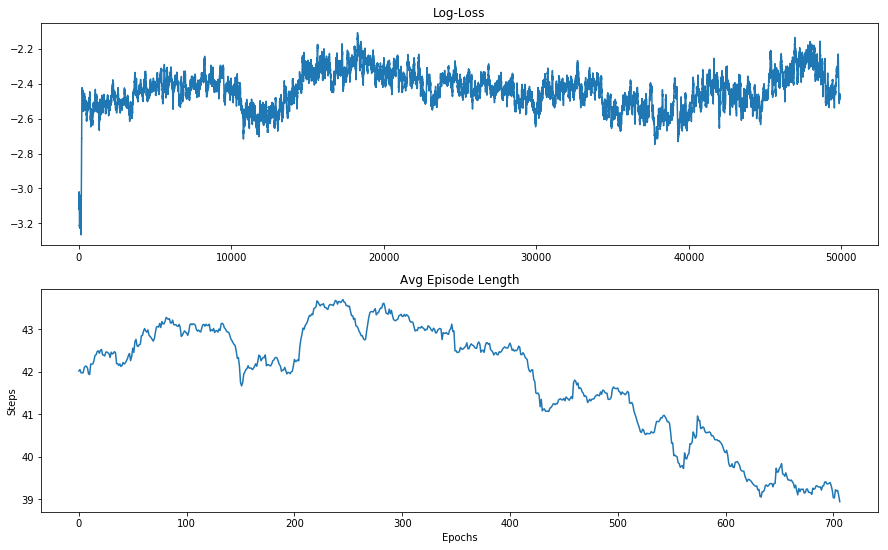

In [0]:
fig,ax = plt.subplots(2,1)
fig.set_size_inches(15,9)
ax[0].set_title("Log-Loss")
ax[0].plot(running_mean(np.log10(np.array(losses))))
ax[1].set_title("Avg Episode Length")
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Steps")
ax[1].plot(running_mean(np.array(avg_rewards),500))

In [0]:
#MiniGrid-DoorKey-5x5-v0, MiniGrid-Empty-5x5-v0, MiniGrid-Empty-Random-5x5-v0
np.random.seed()
test_env = ImgObsWrapper(gym.make('MiniGrid-DoorKey-6x6-v0'))
state=test_env.reset()
maxsteps = 200
test_env.max_steps = maxsteps
test_env.env.max_steps = maxsteps
wins = 0
games = 0
steps = 0
i = 0
while (games < 100):
    #action = action_map[np.random.randint(5)]
    pred = GWagent(prepare_state(state).cuda()).cpu()
    action = action_map[np.random.randint(5)] if np.random.rand() < 0.5 else torch.argmax(pred)
    state, reward, done, info = test_env.step(action)
    steps += 1
    '''if np.random.randint(500) == 400:
        break'''
    if reward > 0:
        #print("Game won at {}".format(steps,))
        wins+=1
    if done:
        games +=1
        steps = 0
        state = test_env.reset()
    i+=1
print("{} / {} = {}%".format(wins,games, (100.0*wins/games)))

NameError: ignored

In [0]:
[x for x in env.env.actions]

[<Actions.left: 0>,
 <Actions.right: 1>,
 <Actions.forward: 2>,
 <Actions.pickup: 3>,
 <Actions.drop: 4>,
 <Actions.toggle: 5>,
 <Actions.done: 6>]

In [0]:
x=torch.randn(5,49,3)
rearrange(x,"batch (h w) c->batch c h w", h=7).shape

torch.Size([5, 3, 7, 7])

In [0]:
state_ = env.reset()
state=prepare_state(state_)
#state_view  = prepare_state(state_)
GWagent(state.cuda()).cpu()

tensor([[-0.2948, -0.3099, -0.2892, -0.2463, -0.2600]],
       grad_fn=<CopyBackwards>)

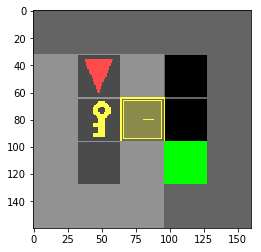

In [0]:
plt.imshow(env.render('rgb_array'))

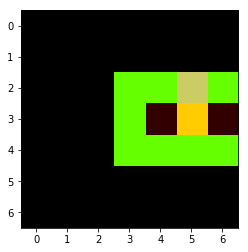

In [0]:
plt.imshow(state[0].permute(1,2,0).detach().numpy())
#plt.axis('off')

In [0]:
#plt.imshow(GWagent.conv_map[0].mean(dim=0).view(7,7))

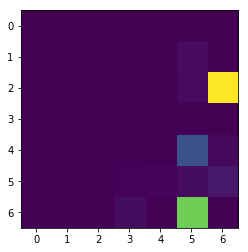

In [0]:
plt.imshow(GWagent.att_map[0][2][26].view(7,7))

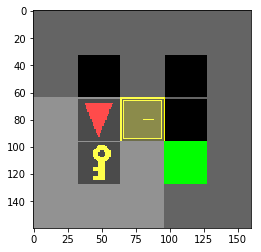

In [0]:
plt.imshow(test_env.render('rgb_array'))